In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('../data/processed/iris_cleaned.csv')
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
le = LabelEncoder()
y = le.fit_transform(df['Species'])

models = {
    'KNN':           KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM':           SVC(kernel='rbf', random_state=42),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("=" * 50)
print("5-FOLD CROSS VALIDATION RESULTS")
print("=" * 50)
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name:<15} Mean: {scores.mean():.4f} | Std: {scores.std():.4f}")

5-FOLD CROSS VALIDATION RESULTS
KNN             Mean: 0.9733 | Std: 0.0249
Decision Tree   Mean: 0.9533 | Std: 0.0267
SVM             Mean: 0.9667 | Std: 0.0298


C:\Users\Annika Dubey\AppData\Local\Temp\ipykernel_24528\379980994.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,


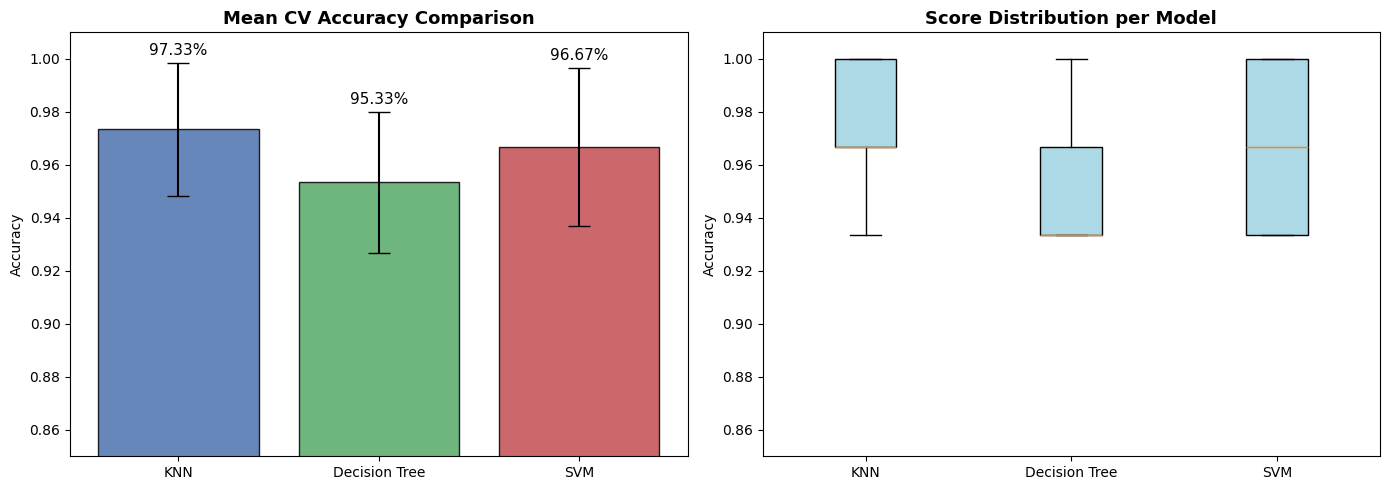

Saved!


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names = list(cv_results.keys())
means = [cv_results[n].mean() for n in names]
stds  = [cv_results[n].std()  for n in names]
colors = ['#4C72B0', '#55A868', '#C44E52']

axes[0].bar(names, means, yerr=stds, color=colors,
            capsize=8, edgecolor='black', alpha=0.85)
axes[0].set_title('Mean CV Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.85, 1.01)
for i, (m, s) in enumerate(zip(means, stds)):
    axes[0].text(i, m + s + 0.003, f'{m:.2%}', ha='center', fontsize=11)

axes[1].boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Score Distribution per Model', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.85, 1.01)

plt.tight_layout()
plt.savefig('../docs/cross_validation.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved!")

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n" + "=" * 55)
print("FULL PROJECT SUMMARY")
print("=" * 55)
print(f"{'Model':<15} {'Test Acc':>10} {'CV Mean':>10} {'CV Std':>10}")
print("-" * 55)
for name, model in models.items():
    model.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test))
    cv_mean  = cv_results[name].mean()
    cv_std   = cv_results[name].std()
    print(f"{name:<15} {test_acc:>10.2%} {cv_mean:>10.2%} {cv_std:>10.4f}")
print("=" * 55)


FULL PROJECT SUMMARY
Model             Test Acc    CV Mean     CV Std
-------------------------------------------------------
KNN                100.00%     97.33%     0.0249
Decision Tree      100.00%     95.33%     0.0267
SVM                100.00%     96.67%     0.0298


Best K for KNN: 13 (accuracy: 0.9800)


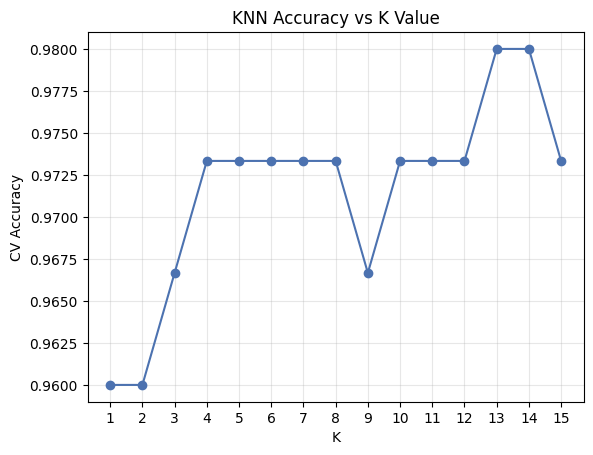

In [4]:
k_scores = []
for k in range(1, 16):
    knn_k = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_k, X, y, cv=kf, scoring='accuracy')
    k_scores.append(scores.mean())

best_k = k_scores.index(max(k_scores)) + 1
print(f"Best K for KNN: {best_k} (accuracy: {max(k_scores):.4f})")

plt.plot(range(1, 16), k_scores, marker='o', color='#4C72B0')
plt.title('KNN Accuracy vs K Value')
plt.xlabel('K')
plt.ylabel('CV Accuracy')
plt.xticks(range(1, 16))
plt.grid(True, alpha=0.3)
plt.savefig('../docs/knn_k_values.png', bbox_inches='tight', dpi=150)
plt.show()